# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [1]:
import torch
from transformers import CLIPModel, CLIPProcessor
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando device:", device)

Usando device: cpu


README.md:   0%|          | 0.00/672 [00:00<?, ?B/s]

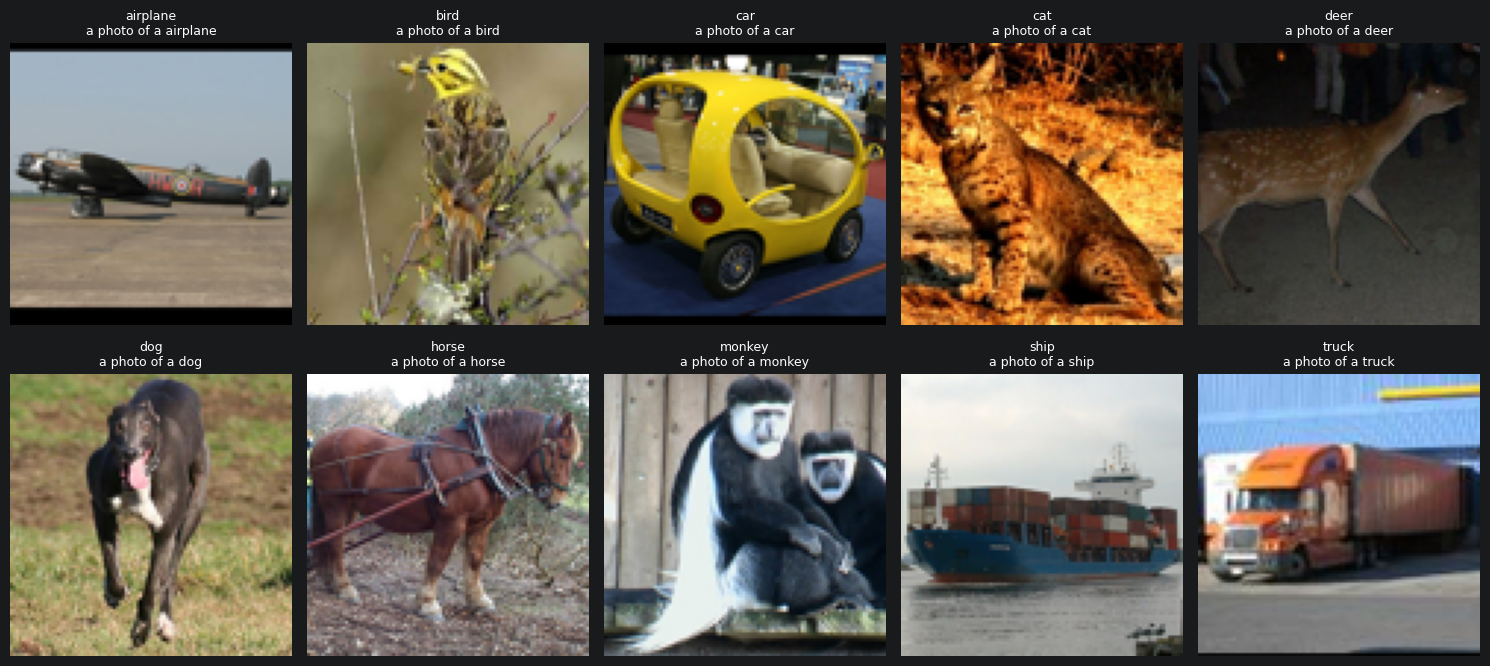

In [3]:
# Cargamos STL-10 en modo streaming (formato Parquet, liviano y rápido de acceder)
hf_dataset = load_dataset("tanganke/stl10", split="train", streaming=True)
class_names = hf_dataset.features["label"].names  # 10 nombres de clase, ej. 'airplane', 'cat', 'ship', ...

# Nos quedamos con la primera imagen que encontremos de cada una de las 10 clases
images, names = [], []
seen = set()
for example in hf_dataset:
    label_id = example["label"]
    if label_id not in seen:
        images.append(example["image"].convert("RGB"))
        names.append(class_names[label_id])
        seen.add(label_id)
    if len(seen) == len(class_names):
        break  # ya conseguimos una imagen de cada clase

texts = [f"a photo of a {name}" for name in names]

# Vistazo rápido al dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, img, name, text in zip(axes.flat, images, names, texts):
    ax.imshow(img)
    ax.set_title(f"{name}\n{text}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

model.eval()

inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

# outputs.image_embeds y outputs.text_embeds YA vienen del espacio compartido de CLIP
image_embeds = outputs.image_embeds.cpu().numpy()
text_embeds = outputs.text_embeds.cpu().numpy()

print("Forma embeddings de imagen:", image_embeds.shape)
print("Forma embeddings de texto :", text_embeds.shape)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Forma embeddings de imagen: (10, 512)
Forma embeddings de texto : (10, 512)


In [5]:
def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)

image_embeds_n = normalize(image_embeds)
text_embeds_n = normalize(text_embeds)

print("Norma imagen (debe ser ~1):", np.linalg.norm(image_embeds_n[0]))
print("Norma texto  (debe ser ~1):", np.linalg.norm(text_embeds_n[0]))

Norma imagen (debe ser ~1): 1.0
Norma texto  (debe ser ~1): 1.0


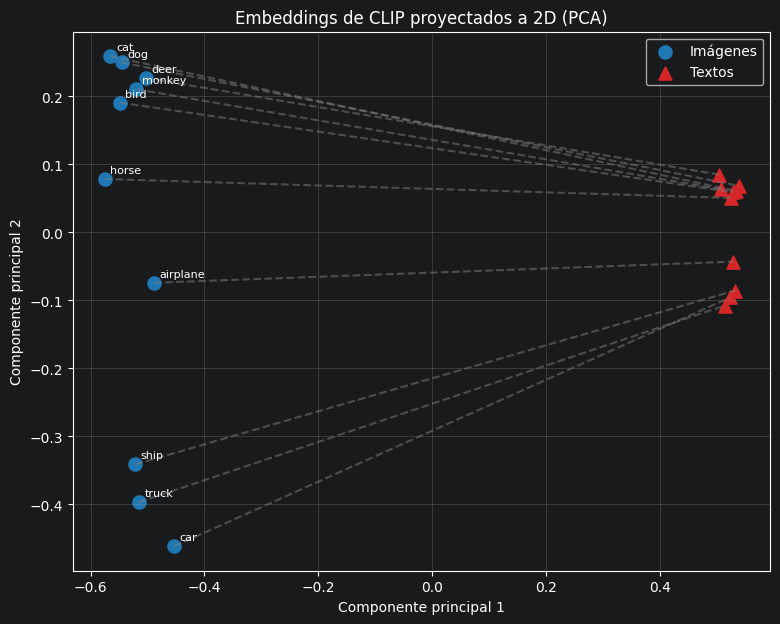

Varianza explicada por las 2 componentes: 59.89%


In [6]:
all_embeds = np.vstack([image_embeds_n, text_embeds_n])  # (2N, D)

pca = PCA(n_components=2, random_state=0)
all_2d = pca.fit_transform(all_embeds)

n = len(images)
img_2d = all_2d[:n]
txt_2d = all_2d[n:]

plt.figure(figsize=(9, 7))
plt.scatter(img_2d[:, 0], img_2d[:, 1], c="tab:blue", s=90, label="Imágenes", marker="o")
plt.scatter(txt_2d[:, 0], txt_2d[:, 1], c="tab:red", s=90, label="Textos", marker="^")

# Dibujamos una línea entre cada imagen y su texto correspondiente (par verdadero)
for i in range(n):
    plt.plot([img_2d[i, 0], txt_2d[i, 0]], [img_2d[i, 1], txt_2d[i, 1]],
              color="gray", linestyle="--", alpha=0.5)
    plt.annotate(names[i], img_2d[i], fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.title("Embeddings de CLIP proyectados a 2D (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

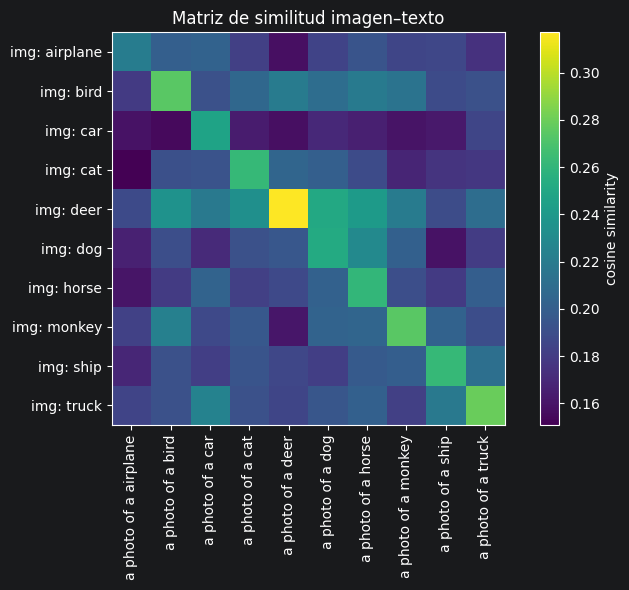

In [7]:
# Matriz de similitud: filas = imágenes, columnas = textos
similarity = image_embeds_n @ text_embeds_n.T   # (N_img, N_txt)

plt.figure(figsize=(8, 6))
plt.imshow(similarity, cmap="viridis")
plt.colorbar(label="cosine similarity")
plt.xticks(range(n), texts, rotation=90)
plt.yticks(range(n), [f"img: {nm}" for nm in names])
plt.title("Matriz de similitud imagen–texto")
plt.tight_layout()
plt.show()

In [8]:
print("=== Búsqueda Texto → Imagen ===")
correct_t2i = 0
for j, txt in enumerate(texts):
    best_i = similarity[:, j].argmax()
    is_correct = (best_i == j)
    correct_t2i += is_correct
    print(f"Texto: {txt!r:45s} -> Imagen más similar: {names[best_i]:10s} "
          f"({'OK' if is_correct else 'ERROR'}, sim={similarity[best_i, j]:.3f})")

print(f"\nAccuracy texto->imagen: {correct_t2i}/{n} = {correct_t2i/n:.1%}")

print("\n=== Búsqueda Imagen → Texto (zero-shot classification) ===")
correct_i2t = 0
for i, name in enumerate(names):
    best_j = similarity[i, :].argmax()
    is_correct = (best_j == i)
    correct_i2t += is_correct
    print(f"Imagen: {name:10s} -> Texto más similar: {texts[best_j]!r:45s} "
          f"({'OK' if is_correct else 'ERROR'}, sim={similarity[i, best_j]:.3f})")

print(f"\nAccuracy imagen->texto: {correct_i2t}/{n} = {correct_i2t/n:.1%}")

=== Búsqueda Texto → Imagen ===
Texto: 'a photo of a airplane'                       -> Imagen más similar: airplane   (OK, sim=0.220)
Texto: 'a photo of a bird'                           -> Imagen más similar: bird       (OK, sim=0.275)
Texto: 'a photo of a car'                            -> Imagen más similar: car        (OK, sim=0.247)
Texto: 'a photo of a cat'                            -> Imagen más similar: cat        (OK, sim=0.262)
Texto: 'a photo of a deer'                           -> Imagen más similar: deer       (OK, sim=0.317)
Texto: 'a photo of a dog'                            -> Imagen más similar: dog        (OK, sim=0.253)
Texto: 'a photo of a horse'                          -> Imagen más similar: horse      (OK, sim=0.261)
Texto: 'a photo of a monkey'                         -> Imagen más similar: monkey     (OK, sim=0.275)
Texto: 'a photo of a ship'                           -> Imagen más similar: ship       (OK, sim=0.262)
Texto: 'a photo of a truck'              